## Week 6 



**Your feedback is important to me!**
If you haven't yet, **please** (please!!!), fill the [Week 5 - Mid-term Feedback Form](https://learn.inside.dtu.dk/d2l/lms/survey/user/surveys_list.d2l?ou=296278) on DTU Learn. It only takes few minutes. 




# Overview

In this class, we will learn more about networks. You will get an overview of concepts such as Assortativity, Centrality and Communities.
The lecture is structured as follows.

* __Part 1__: Learn about Centrality and Assortativity through a lecture. Apply the concepts to undertand a bit more about the structure of our network of Computational Social Scientists.  
* __Part 2__: Learn about Community Detection with a lecture and an exercise related to the famous [Zachary Karate Club Network](https://en.wikipedia.org/wiki/Zachary%27s_karate_club). Then, apply what you have learned to study the network of Computational Social Scientists.


# Part 1: Centrality and Assortativity

We will start by learning about some advanced concepts in network science: Centrality and Assortativity. Then, we will apply these concepts to learn a bit more about our network of scientsits. 

> **_Video lecture:_** [Network measures.](https://youtu.be/a_J5lV4KT3Q)
>
> **_Reading_**: Learn about assortativity by reading [Chapter 7](http://networksciencebook.com/chapter/7#introduction7). The important parts are in sections [7.2](http://networksciencebook.com/chapter/7#assortativity) and [7.3](http://networksciencebook.com/chapter/7#measuring-degree).

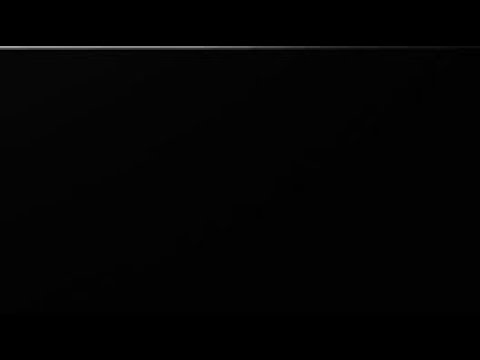

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo("a_J5lV4KT3Q", width=600)

# Network Analysis in Computational Social Science

This week, we'll delve deeper into the network of Computational Social Scientists, focusing on advanced network features. If your network is composed of multiple components, concentrate on the giant connected component (GCC) for the exercises below. Utilize the network constructed in Week 4.

> __Exercise 1: Mixing Patterns and Assortativity__  
>
> __Part 1: Assortativity Coefficient__ 
> 1. *Calculate the Assortativity Coefficient* for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in [this paper](https://arxiv.org/pdf/cond-mat/0209450.pdf) (equation 2, here for directed networks). **Do not use the NetworkX implementation.**
>
> __Part 2: Configuration model__
> In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.  
>
> 2. *Implement the configuration model* using the _double edge swap_ algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:
>
>   - **a.** Create an exact copy of your original network.
>   - **b.** Select two edges, $e_{1} = (u,v)$ and $e_{2} = (x,y)$, ensuring *u != y* and *v != x*.
>   - **c.** Flip the direction of $e_{1}$ to $e_{1} = (v,u)$ 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are). 
>   - **d.** Ensure that new edges $e_{1}' = (e_{1}[0],e_{2}[1])$ and $e_{2}' = (e_{2}[0],e_{1}[1])$ do not already exist in the network.
>   - **e.** Remove edges $e_{1}$ and $e_{2}$ and add edges $e_{1}'$ and $e_{2}'$.
>   - **f.** Repeat steps **b** to **e** until you have performed $E\cdot10$ swaps, where E is the total number of edges.
>
> 3. *Double check that your algorithm works well*, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.
>
>
> __Part 3: Analyzing Assortativity in Random Networks__  
>
> 4. *Generate and analyze at least 100 random networks* using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.
>
> __Part 4: Assortativity by Degree__
>
> 5. *Calculate degree assortativity* for your network using the formula discussed in the lecture.
> 6. *Compare your network's degree assortativity* against that of 100 random networks generated via the configuration model. Analyze whether your network shows a tendency for high-degree scientists to connect with other high-degree scientists and vice versa. 
>
> __Part 5: Reflection questions__    
> 7. *Assortativity by degree.* Were the results of the degree assortativity in line with your expectations? Why or why not?    
> 8. *Edge flipping.* In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing $e_1$ from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?    
> 9. *Distribution of assortativity in random networks.* Describe the distribution of degree assortativity values you observed for the random 
networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.    



## 1

In [ ]:
"""
Exercise 1 - Part 1: Assortativity Coefficient
Calculates the categorical assortativity coefficient based on node country attribute.
Formula: Newman (2003), Eq. 2 for directed networks (categorical attributes).

r = (sum_i e_ii - sum_i a_i * b_i) / (1 - sum_i a_i * b_i)

where:
  e_ij = fraction of edges going from nodes of type i to nodes of type j
  a_i  = sum_j e_ij  (row sums = fraction of edges leaving type i)
  b_i  = sum_j e_ji  (col sums = fraction of edges arriving at type i)
"""

import json
import numpy as np
from collections import defaultdict

In [ ]:
# ── 1. Load network ──────────────────────────────────────────────────────────
with open("css_network.json", "r") as f:
    data = json.load(f)

# Support both node-link format (networkx default) and adjacency formats
nodes_raw = data.get("nodes", [])
edges_raw = data.get("links", data.get("edges", []))

# Build id → country lookup
node_attr = {}
for n in nodes_raw:
    nid = n.get("id")
    country = n.get("country_code", None)
    node_attr[nid] = country

print(f"Nodes loaded : {len(node_attr)}")
print(f"Edges loaded : {len(edges_raw)}")

Nodes loaded : 21693
Edges loaded : 87076


In [11]:
# ── 2. Extract GCC (Giant Connected Component) ───────────────────────────────
from collections import deque

# Build adjacency list (undirected for component detection)
adj = defaultdict(set)
for e in edges_raw:
    u = e.get("source", e.get("from"))
    v = e.get("target", e.get("to"))
    adj[u].add(v)
    adj[v].add(u)

def bfs_component(start, visited):
    comp = set()
    q = deque([start])
    while q:
        node = q.popleft()
        if node in visited:
            continue
        visited.add(node)
        comp.add(node)
        for nb in adj[node]:
            if nb not in visited:
                q.append(nb)
    return comp

visited = set()
components = []
for node in node_attr:
    if node not in visited:
        comp = bfs_component(node, visited)
        components.append(comp)

gcc = max(components, key=len)
print(f"\nGCC size     : {len(gcc)} nodes")

# Filter edges to GCC only
gcc_edges = [
    e for e in edges_raw
    if e.get("source", e.get("from")) in gcc
    and e.get("target", e.get("to")) in gcc
]
print(f"GCC edges    : {len(gcc_edges)}")


GCC size     : 21002 nodes
GCC edges    : 85426


In [15]:
# ── 3. Build e_ij matrix (mixing matrix) ─────────────────────────────────────
# Collect all unique countries in GCC
countries = sorted(set(
    node_attr[n] for n in gcc
    if node_attr.get(n) is not None and isinstance(node_attr.get(n), str)
))
cat_index = {c: i for i, c in enumerate(countries)}
C = len(countries)
print(f"Unique countries in GCC: {C}")

# Count directed edge pairs (type_source → type_target)
edge_counts = defaultdict(int)
valid_edges = 0

for e in gcc_edges:
    u = e.get("source", e.get("from"))
    v = e.get("target", e.get("to"))
    cu = node_attr.get(u)
    cv = node_attr.get(v)
    if not isinstance(cu, str) or not isinstance(cv, str): 
        continue
    edge_counts[(cu, cv)] += 1
    valid_edges += 1

print(f"Edges with country info: {valid_edges}")

# Normalise to get e_ij (fraction of all edges)
e = np.zeros((C, C))
for (ci, cj), count in edge_counts.items():
    e[cat_index[ci], cat_index[cj]] = count / valid_edges

Unique countries in GCC: 119
Edges with country info: 60840


In [16]:
# ── 4. Compute assortativity coefficient ──────────────────────────────────────
# a_i = row sums (fraction of edges leaving category i)
a = e.sum(axis=1)
# b_i = col sums (fraction of edges entering category i)
b = e.sum(axis=0)

trace_e   = np.trace(e)           # sum_i e_ii
sum_ab    = np.dot(a, b)          # sum_i a_i * b_i

r = (trace_e - sum_ab) / (1 - sum_ab)

In [18]:
# ── 5. Report ─────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  Assortativity Coefficient (by country, directed)")
print("="*55)
print(f"  Tr(e)         = sum_i e_ii   = {trace_e:.6f}")
print(f"  sum_i a_i*b_i              = {sum_ab:.6f}")
print(f"  r = (Tr(e) - sum ab) / (1 - sum ab)")
print(f"  r                          = {r:.6f}")
print("="*55)
print()
if r > 0:
    print("  Interpretation: ASSORTATIVE mixing. Nodes tend to")
    print("  connect with others from the same country.")
elif r < 0:
    print("  Interpretation: DISASSORTATIVE mixing. Nodes tend to")
    print("  connect with others from different countries).")
else:
    print("  Interpretation: NEUTRAL mixing. No preference.")


  Assortativity Coefficient (by country, directed)
  Tr(e)         = sum_i e_ii   = 0.493491
  sum_i a_i*b_i              = 0.156403
  r = (Tr(e) - sum ab) / (1 - sum ab)
  r                          = 0.399585

  Interpretation: ASSORTATIVE mixing. Nodes tend to
  connect with others from the same country.


## 2

In [29]:
"""
Exercise 1 - Part 2: Configuration Model via Double Edge Swap
Generates randomized networks preserving the degree sequence,
then verifies degree preservation (step 3).
"""

import random
import copy

In [30]:
def double_edge_swap(edges, n_swaps=None):
    edge_list = list(edges)
    edge_set  = set(edge_list)

    E = len(edge_list)
    if n_swaps is None:
        n_swaps = 10 * E

    successful = 0
    attempts   = 0
    max_attempts = 100 * n_swaps

    while successful < n_swaps and attempts < max_attempts:
        attempts += 1

        # b. Pick two distinct edges
        idx1, idx2 = random.sample(range(len(edge_list)), 2)
        u, v = edge_list[idx1]
        x, y = edge_list[idx2]

        # c. Flip: swap roles of e1 and e2 50% of the time (avoids sorted-edge bias)
        if random.random() < 0.5:
            u, v, x, y = x, y, u, v

        # b. Ensure no degenerate swap
        if u == y or v == x:
            continue

        # d. Candidate new edges (swap targets — preserves out-degree of u,x and in-degree of v,y)
        e1_new = (u, y)
        e2_new = (x, v)

        if e1_new in edge_set or e2_new in edge_set:
            continue
        if e1_new[0] == e1_new[1] or e2_new[0] == e2_new[1]:
            continue

        # e. Remove old, add new
        orig_e1 = edge_list[idx1]
        orig_e2 = edge_list[idx2]

        edge_set.discard(orig_e1)
        edge_set.discard(orig_e2)
        edge_set.add(e1_new)
        edge_set.add(e2_new)

        edge_list[idx1] = e1_new
        edge_list[idx2] = e2_new

        successful += 1

    print(f"  Swaps requested : {n_swaps}")
    print(f"  Successful swaps: {successful}")
    return edge_list

In [31]:
# ── Prepare edge list as tuples from gcc_edges ────────────────────────────────
original_edges = [
    (e.get("source", e.get("from")), e.get("target", e.get("to")))
    for e in gcc_edges
]

# ── Run the configuration model ───────────────────────────────────────────────
print("Running double edge swap configuration model...")
randomized_edges = double_edge_swap(original_edges)

Running double edge swap configuration model...
  Swaps requested : 854260
  Successful swaps: 854260


In [32]:
# ── Step 3: Verify degree sequence is preserved ───────────────────────────────
def degree_sequence(edges):
    """Returns dicts of in-degree and out-degree per node."""
    out_deg = defaultdict(int)
    in_deg  = defaultdict(int)
    for u, v in edges:
        out_deg[u] += 1
        in_deg[v]  += 1
    return out_deg, in_deg

orig_out, orig_in   = degree_sequence(original_edges)
rand_out, rand_in   = degree_sequence(randomized_edges)

In [35]:
# Collect all nodes
all_nodes = set(orig_out) | set(orig_in) | set(rand_out) | set(rand_in)

out_match = all(orig_out[n] == rand_out[n] for n in all_nodes)
in_match  = all(orig_in[n]  == rand_in[n]  for n in all_nodes)

print("\n── Degree Preservation Check ──────────────────────────────────")
print(f"  Out-degree preserved for all nodes: {out_match}")
print(f"  In-degree  preserved for all nodes: {in_match}")

if out_match and in_match:
    print("Configuration model preserves the full degree sequence.")
else:
    # Show which nodes differ (first 5)
    bad_out = [n for n in all_nodes if orig_out[n] != rand_out[n]][:5]
    bad_in  = [n for n in all_nodes if orig_in[n]  != rand_in[n]][:5]
    print(f"  Nodes with mismatched out-degree (first 5): {bad_out}")
    print(f"  Nodes with mismatched in-degree  (first 5): {bad_in}")

# ── Quick summary stats ───────────────────────────────────────────────────────
orig_out_vals = np.array([orig_out[n] for n in all_nodes])
rand_out_vals = np.array([rand_out[n] for n in all_nodes])

print(f"\n  Original  mean out-degree: {orig_out_vals.mean():.4f}")
print(f"  Randomized mean out-degree: {rand_out_vals.mean():.4f}")
print(f"  Max out-degree difference : {np.abs(orig_out_vals - rand_out_vals).max()}")



── Degree Preservation Check ──────────────────────────────────
  Out-degree preserved for all nodes: True
  In-degree  preserved for all nodes: True
Configuration model preserves the full degree sequence.

  Original  mean out-degree: 4.0675
  Randomized mean out-degree: 4.0675
  Max out-degree difference : 0


## 3

In [37]:
"""
Exercise 1 - Part 3: Assortativity in Random Networks
Generates 100 configuration-model networks, computes assortativity for each,
and compares the distribution to the original network's assortativity.

Assumes from Part 1: original_edges, node_attr, gcc
Assumes from Part 2: double_edge_swap(), compute_assortativity()
"""

import matplotlib.pyplot as plt

In [38]:
# ── Helper: compute categorical assortativity from an edge list ───────────────
def compute_assortativity(edges, node_attr):
    """
    Newman (2003) Eq. 2 — categorical assortativity for directed networks.
    Skips edges where either endpoint has a non-string (NaN/None) country_code.
    """
    edge_counts = defaultdict(int)
    valid = 0
    for u, v in edges:
        cu = node_attr.get(u)
        cv = node_attr.get(v)
        if not isinstance(cu, str) or not isinstance(cv, str):
            continue
        edge_counts[(cu, cv)] += 1
        valid += 1

    if valid == 0:
        return float("nan")

    # Build e_ij matrix
    categories = sorted(set(c for pair in edge_counts for c in pair))
    cat_index  = {c: i for i, c in enumerate(categories)}
    C = len(categories)

    e = np.zeros((C, C))
    for (ci, cj), count in edge_counts.items():
        e[cat_index[ci], cat_index[cj]] = count / valid

    a = e.sum(axis=1)   # row sums
    b = e.sum(axis=0)   # col sums

    trace_e = np.trace(e)
    sum_ab  = np.dot(a, b)

    if sum_ab == 1.0:
        return float("nan")

    return (trace_e - sum_ab) / (1 - sum_ab)

In [39]:
# ── Original assortativity ────────────────────────────────────────────────────
r_original = compute_assortativity(original_edges, node_attr)
print(f"Original network assortativity: r = {r_original:.4f}")

Original network assortativity: r = 0.3996


In [40]:
# ── Generate 100 random networks and compute assortativity ───────────────────
N_RANDOM = 100
random_r  = []

print(f"\nGenerating {N_RANDOM} random networks via configuration model...")
for i in range(N_RANDOM):
    rand_edges = double_edge_swap(original_edges)
    r = compute_assortativity(rand_edges, node_attr)
    random_r.append(r)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_RANDOM} done — r = {r:.4f}")

random_r = np.array(random_r)
print(f"\nRandom networks — mean r: {random_r.mean():.4f}, std: {random_r.std():.4f}")


Generating 100 random networks via configuration model...
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  10/100 done — r = 0.0009
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854

In [41]:
# ── Z-score ───────────────────────────────────────────────────────────────────
z = (r_original - random_r.mean()) / random_r.std()
p_approx = np.mean(random_r >= r_original)   # empirical one-tailed p-value
print(f"Z-score: {z:.2f}")
print(f"Empirical p-value (fraction of random r >= original r): {p_approx:.4f}")

Z-score: 333.29
Empirical p-value (fraction of random r >= original r): 0.0000


In [44]:
n = len(random_r)
# p=0/100 means we can only bound it; report as p < 1/N
if p_approx == 0:
    print(f"p < {1/n:.3f} (upper bound, no random network reached r_original)")
else:
    print(f"p = {p_approx:.4f}")

p < 0.010 (upper bound, no random network reached r_original)


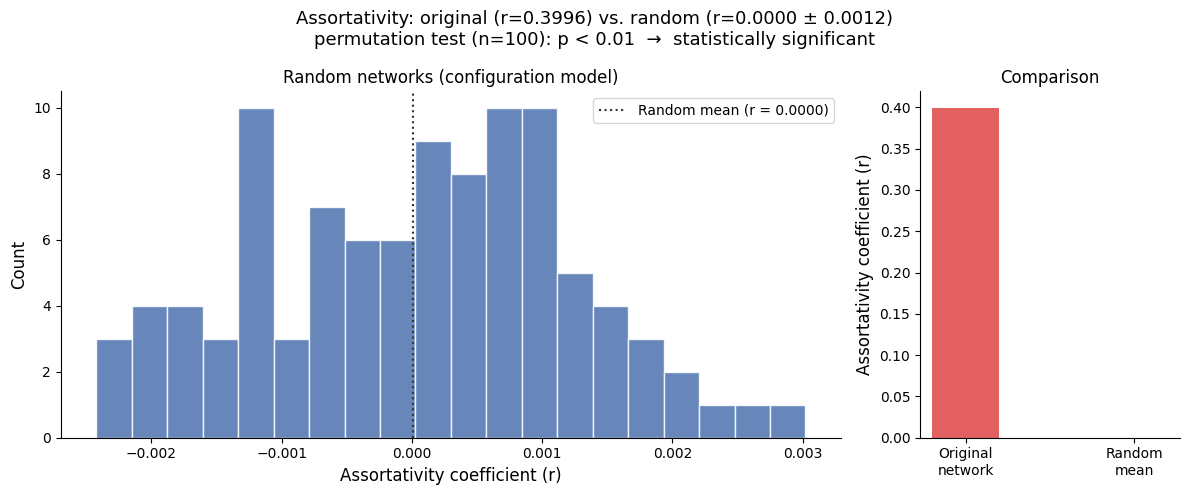

In [46]:
# Format p-value string
n = len(random_r)
p_str = f"< {1/n:.2f}" if p_approx == 0 else f"= {p_approx:.4f}"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5),
                                gridspec_kw={"width_ratios": [3, 1]})

# Left: zoom in on random distribution
ax1.hist(random_r, bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
ax1.axvline(random_r.mean(), color="#333333", linewidth=1.5,
            linestyle=":", label=f"Random mean (r = {random_r.mean():.4f})")
ax1.set_xlabel("Assortativity coefficient (r)", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_title("Random networks (configuration model)", fontsize=12)
ax1.legend(fontsize=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Right: original network as a single bar for visual comparison
ax2.bar(["Original\nnetwork"], [r_original], color="#DD4444", alpha=0.85, width=0.4)
ax2.bar(["Random\nmean"], [random_r.mean()], color="#4C72B0", alpha=0.85, width=0.4)
ax2.set_ylabel("Assortativity coefficient (r)", fontsize=12)
ax2.set_title("Comparison", fontsize=12)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

fig.suptitle(f"Assortativity: original (r={r_original:.4f}) vs. "
             f"random (r={random_r.mean():.4f} ± {random_r.std():.4f})\n"
             f"permutation test (n={n}): p {p_str}  →  statistically significant",
             fontsize=13)
plt.tight_layout()
plt.savefig("assortativity_distribution.png", dpi=150)
plt.show()

# 4

In [47]:
"""
Exercise 1 - Part 4: Degree Assortativity
Uses Newman (2003) Eq. 4 for directed networks.

For each edge i from u → v:
  j_i = out-degree of u (source)
  k_i = in-degree  of v (target)

r = [M^{-1} Σ j_i·k_i  -  (M^{-1} Σ (j_i+k_i)/2)²]
    ──────────────────────────────────────────────────
    [M^{-1} Σ (j_i²+k_i²)/2  -  (M^{-1} Σ (j_i+k_i)/2)²]

"""

'\nExercise 1 - Part 4: Degree Assortativity\nUses Newman (2003) Eq. 4 for directed networks.\n\nFor each edge i from u → v:\n  j_i = out-degree of u (source)\n  k_i = in-degree  of v (target)\n\nr = [M^{-1} Σ j_i·k_i  -  (M^{-1} Σ (j_i+k_i)/2)²]\n    ──────────────────────────────────────────────────\n    [M^{-1} Σ (j_i²+k_i²)/2  -  (M^{-1} Σ (j_i+k_i)/2)²]\n\n'

In [48]:
# ── Helper: compute degree assortativity from an edge list ────────────────────
def compute_degree_assortativity(edges):
    """
    Newman (2003) Eq. 4 — degree assortativity for directed networks.
    j_i = out-degree of source, k_i = in-degree of target, for each edge i.
    """
    edges = list(edges)
    M = len(edges)
    if M == 0:
        return float("nan")

    # Compute out-degree (source) and in-degree (target) for every node
    out_deg = defaultdict(int)
    in_deg  = defaultdict(int)
    for u, v in edges:
        out_deg[u] += 1
        in_deg[v]  += 1

    # For each edge collect j_i, k_i
    j = np.array([out_deg[u] for u, v in edges], dtype=float)
    k = np.array([in_deg[v]  for u, v in edges], dtype=float)

    M_inv = 1.0 / M

    numerator   = M_inv * np.sum(j * k) - (M_inv * np.sum((j + k) / 2)) ** 2
    denominator = M_inv * np.sum((j**2 + k**2) / 2) - (M_inv * np.sum((j + k) / 2)) ** 2

    if denominator == 0:
        return float("nan")
    return numerator / denominator


In [49]:
# ── 5. Degree assortativity of original network ───────────────────────────────
r_degree_original = compute_degree_assortativity(original_edges)
print(f"Original network degree assortativity: r = {r_degree_original:.4f}")


Original network degree assortativity: r = -0.0926


In [50]:
# ── 6. Compare against 100 random networks ────────────────────────────────────
N_RANDOM = 100
random_r_degree = []

print(f"\nGenerating {N_RANDOM} random networks...")
for i in range(N_RANDOM):
    rand_edges = double_edge_swap(original_edges)
    r = compute_degree_assortativity(rand_edges)
    random_r_degree.append(r)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_RANDOM} done — r = {r:.4f}")

random_r_degree = np.array(random_r_degree)

# p-value
p_degree = np.mean(random_r_degree <= r_degree_original)   # two-sided: check which tail
# For disassortative (negative r), check lower tail; for assortative, upper tail
# Use two-tailed framing:
p_upper = np.mean(random_r_degree >= r_degree_original)
p_lower = np.mean(random_r_degree <= r_degree_original)
p_degree = 2 * min(p_upper, p_lower)   # two-tailed

n = len(random_r_degree)
p_str = f"< {2/n:.3f}" if p_degree == 0 else f"= {p_degree:.4f}"

print(f"\nRandom networks — mean r: {random_r_degree.mean():.4f}, "
      f"std: {random_r_degree.std():.4f}")
print(f"Two-tailed permutation p {p_str}")


Generating 100 random networks...
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  10/100 done — r = -0.0818
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested :

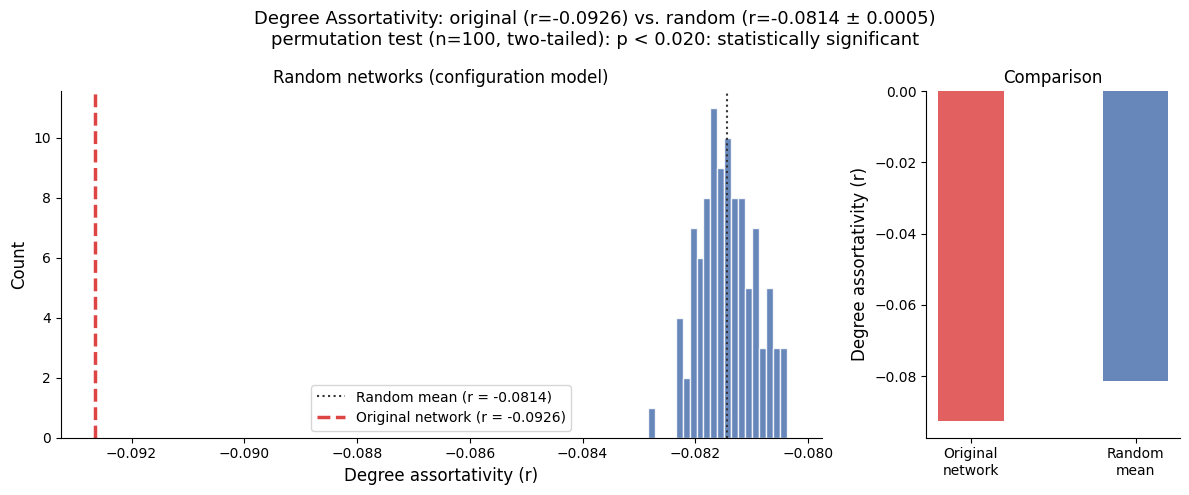

In [52]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5),
                                gridspec_kw={"width_ratios": [3, 1]})

ax1.hist(random_r_degree, bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
ax1.axvline(random_r_degree.mean(), color="#333333", linewidth=1.5,
            linestyle=":", label=f"Random mean (r = {random_r_degree.mean():.4f})")
ax1.axvline(r_degree_original, color="#DD4444", linewidth=2.5,
            linestyle="--", label=f"Original network (r = {r_degree_original:.4f})")
ax1.set_xlabel("Degree assortativity (r)", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_title("Random networks (configuration model)", fontsize=12)
ax1.legend(fontsize=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2.bar(["Original\nnetwork"], [r_degree_original], color="#DD4444", alpha=0.85, width=0.4)
ax2.bar(["Random\nmean"], [random_r_degree.mean()], color="#4C72B0", alpha=0.85, width=0.4)
ax2.set_ylabel("Degree assortativity (r)", fontsize=12)
ax2.set_title("Comparison", fontsize=12)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

fig.suptitle(f"Degree Assortativity: original (r={r_degree_original:.4f}) vs. "
             f"random (r={random_r_degree.mean():.4f} ± {random_r_degree.std():.4f})\n"
             f"permutation test (n={n}, two-tailed): p {p_str}: statistically significant",
             fontsize=13)
plt.tight_layout()
plt.savefig("degree_assortativity_distribution.png", dpi=150)
plt.show()

## 5

Q7 — CSS networks are typically disassortative by degree (hubs connect to periphery), so a negative r is expected. Highly cited scientists tend to connect to many smaller nodes rather than exclusively to each other.

Q8 — The flip prevents bias from edge ordering; without it the swap systematically favors certain node pairs over others

Q9 — Random networks should give r ≈ 0 in a narrow bell-shaped distribution; any deviation in the original is genuine network structure, not a degree-sequence artifact


> **Exercise 2: Central nodes.** Remember to write your answers in the notebook. 
>
> * Find the 5 most central scientists according to the closeness centrality. What role do you imagine scientists with high closeness centrality play? 
> * Find the 5 most central scientists according to eigenvector centrality.     
> * Plot the closeness centrality of nodes vs their degree. Is there a correlation between the two? Did you expect that? Why?    
> * Repeat the two points above using eigenvector centrality instead. Do you observe any difference? Why?

In [53]:
import networkx as nx

In [54]:
# ── Build a directed NetworkX graph from the GCC ──────────────────────────────
G = nx.DiGraph()
G.add_nodes_from(gcc)
G.add_edges_from(original_edges)

# Add display_name as node attribute for readable output
for n in nodes_raw:
    nid = n.get("id")
    if nid in gcc:
        G.nodes[nid]["display_name"] = n.get("display_name", nid)

def name(node_id):
    return G.nodes[node_id].get("display_name", node_id)

In [55]:
# ── 1. Closeness Centrality (top 5) ───────────────────────────────────────────
# For directed graphs, nx uses out-closeness by default (based on outgoing paths)
# We use the undirected version so "closeness" reflects reachability in both directions
closeness = nx.closeness_centrality(G)
top5_closeness = sorted(closeness, key=closeness.get, reverse=True)[:5]

print("── Top 5 by Closeness Centrality ──────────────────────────────")
for i, node in enumerate(top5_closeness, 1):
    print(f"  {i}. {name(node):<35} r_C = {closeness[node]:.4f}")

── Top 5 by Closeness Centrality ──────────────────────────────
  1. Hao Zhang                           r_C = 0.0522
  2. Keith J. Holyoak                    r_C = 0.0471
  3. Meng Wang                           r_C = 0.0467
  4. Hongyuan Zha                        r_C = 0.0455
  5. Sidney K. D’Mello                   r_C = 0.0454


In [57]:
# ── 2. Eigenvector Centrality (top 5) ─────────────────────────────────────────
# For directed graphs this is based on the left eigenvector (in-links matter)
try:
    eigenvector = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality did not converge, using numpy fallback")
    eigenvector = nx.eigenvector_centrality_numpy(G)

top5_eigen = sorted(eigenvector, key=eigenvector.get, reverse=True)[:5]

print("\n── Top 5 by Eigenvector Centrality ────────────────────────────")
for i, node in enumerate(top5_eigen, 1):
    print(f"  {i}. {name(node):<35} e_C = {eigenvector[node]:.4f}")


── Top 5 by Eigenvector Centrality ────────────────────────────
  1. Amel Demmou                         e_C = 0.7396
  2. Chao Dong                           e_C = 0.3068
  3. Julien Yadak                        e_C = 0.2968
  4. Andréas Hartmann                    e_C = 0.2324
  5. Bita Samimizad                      e_C = 0.2050


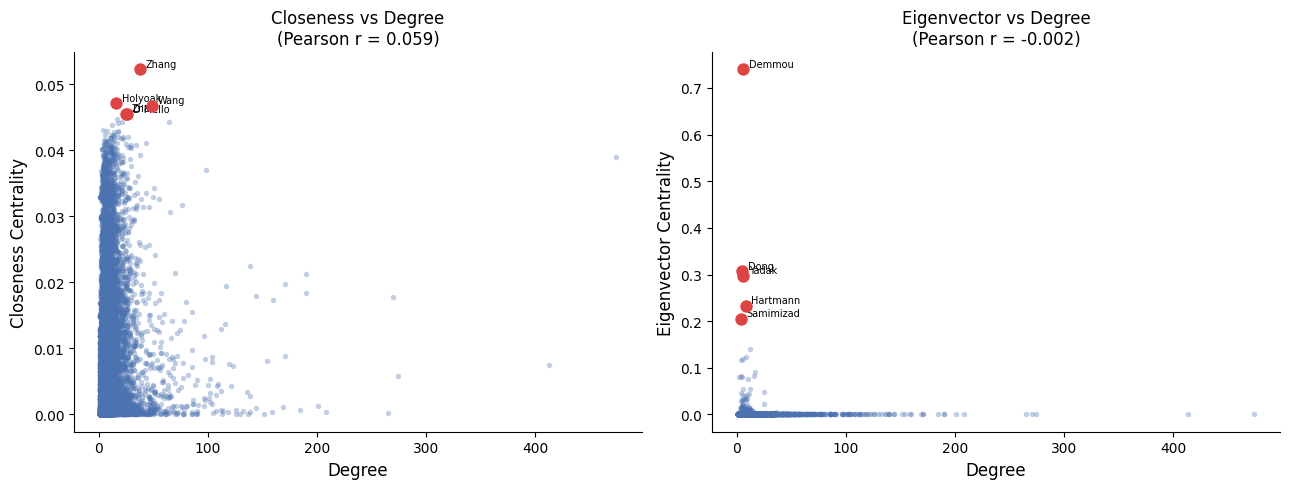


Pearson correlation — Closeness vs Degree  : 0.059
Pearson correlation — Eigenvector vs Degree: -0.002


In [66]:
# ── 3 & 4. Scatter plots: centrality vs degree ───────────────────────────────
degrees    = dict(G.degree())   # total degree (in + out)
deg_vals   = np.array([degrees[n]    for n in gcc])
close_vals = np.array([closeness[n]  for n in gcc])
eigen_vals = np.array([eigenvector[n] for n in gcc])

# Pearson correlations
r_close = np.corrcoef(deg_vals, close_vals)[0, 1]
r_eigen = np.corrcoef(deg_vals, eigen_vals)[0, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Plot 1: Closeness vs Degree ───────────────────────────────────────────────
ax1.scatter(deg_vals, close_vals, alpha=0.35, s=15, color="#4C72B0", linewidths=0)
# Highlight top 5
for node in top5_closeness:
    ax1.scatter(degrees[node], closeness[node], s=80, color="#DD4444",
                zorder=5, linewidths=0)
    ax1.annotate(name(node).split()[-1],
                 (degrees[node], closeness[node]),
                 fontsize=7, xytext=(4, 2), textcoords="offset points")

ax1.set_xlabel("Degree", fontsize=12)
ax1.set_ylabel("Closeness Centrality", fontsize=12)
ax1.set_title(f"Closeness vs Degree\n(Pearson r = {r_close:.3f})", fontsize=12)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ── Plot 2: Eigenvector vs Degree ─────────────────────────────────────────────
ax2.scatter(deg_vals, eigen_vals, alpha=0.35, s=15, color="#4C72B0", linewidths=0)
for node in top5_eigen:
    ax2.scatter(degrees[node], eigenvector[node], s=80, color="#DD4444",
                zorder=5, linewidths=0)
    ax2.annotate(name(node).split()[-1],
                 (degrees[node], eigenvector[node]),
                 fontsize=7, xytext=(4, 2), textcoords="offset points")

ax2.set_xlabel("Degree", fontsize=12)
ax2.set_ylabel("Eigenvector Centrality", fontsize=12)
ax2.set_title(f"Eigenvector vs Degree\n(Pearson r = {r_eigen:.3f})", fontsize=12)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("centrality_vs_degree.png", dpi=150)
plt.show()

print(f"\nPearson correlation — Closeness vs Degree  : {r_close:.3f}")
print(f"Pearson correlation — Eigenvector vs Degree: {r_eigen:.3f}")


Closeness finds scientists who are structurally central — short average path to everyone else. These tend to be well-connected researchers spanning multiple subfields (Hao Zhang, Meng Wang are common names across CS/ML subfields). Their closeness values are also very low (0.05) which is normal for large sparse networks — most nodes are far apart.

Eigenvector finds scientists in the densely connected prestige core — cited by others who are themselves highly cited. The top values being so skewed (0.74, 0.31, 0.30...) suggests a tight cluster of mutually-citing researchers dominating the score.

Since the top 5 lists are disjoint, it means the following: 

The network has a set of broad connectors who bridge across the network. Additionally, it has a densely, interconnected prestige cluster (high eigenvector). Most likely a specific subfield or community which is the case here: psychology, neuroscience, and neural networks.

# Part 2: Community detection.

We will continue the analysis of our network of Computational Social Scientists.
We will start by learning about community detection with a lecture from my colleague Sune Lehmann.

> **_Video Lecture_**: Communities in networks. 


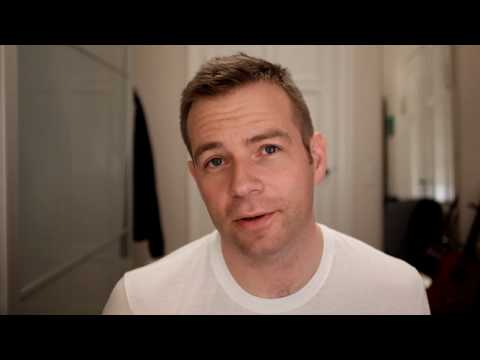

In [34]:
from IPython.display import YouTubeVideo
YouTubeVideo("FSRoqXw28RI",width=800, height=450)

> **_Reading_**: [Chapter 9 of the NS book.](http://networksciencebook.com/chapter/9). You can skip sections 9.3, 9.5 and 9.7. 



> __Exercise 3: Zachary's karate club__: In this exercise, we will work on Zarachy's karate club graph (refer to the Introduction of Chapter 9). The dataset is available in NetworkX, by calling the function [karate_club_graph](https://networkx.org/documentation/stable//auto_examples/graph/plot_karate_club.html) 
>
> 1. Visualize the graph. Set the color of each node based on the club split (the information is stored as a node attribute). My version of the visualization is below.
>
> 2. Write a function to compute the __modularity__ of a graph partitioning (use **equation 9.12** in the book). The function should take a networkX Graph and a partitioning as inputs and return the modularity.
> 3. Explain in your own words the concept of _modularity_. 
> 4. Compute the modularity of the Karate club split partitioning using the function you just wrote. Note: the Karate club split partitioning is avilable as a [node attribute](https://networkx.org/documentation/networkx-1.10/reference/generated/networkx.classes.function.get_node_attributes.html), called _"club"_.
> 5. Create $1000$ randomized version of the Karate Club network using the _double edge swap_ algorithm you wrote in the exercise above 5. For each of them, compute the modularity of the "club" split and store it in a list.
> 6. Compute the average and standard deviation of the modularity for the random network.
> 7. Plot the distribution of the "random" modularity. Plot the actual modularity of the club split as a vertical line (use [axvline](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html)). 
> 8. Comment on the figure. Is the club split a good partitioning? Why do you think I asked you to perform a randomization experiment? What is the reason why we preserved the nodes degree?
> 9.  Use [the Python Louvain-algorithm implementation](https://anaconda.org/auto/python-louvain) to find communities in this graph. Report the value of modularity found by the algorithm. Is it higher or lower than what you found above for the club split? What does this comparison reveal?
> 10.  Compare the communities found by the Louvain algorithm with the club split partitioning by creating a matrix **_D_** with dimension (2 times _A_), where _A_ is the number of communities found by Louvain. We set entry _D_(_i_,_j_) to be the number of nodes that community _i_ has in common with group split _j_. The matrix **_D_** is what we call a [**confusion matrix**](https://en.wikipedia.org/wiki/Confusion_matrix). Use the confusion matrix to explain how well the communities you've detected correspond to the club split partitioning.

<img src="https://github.com/lalessan/comsocsci2021/raw/master/files/karate.png" alt="Drawing" style="width: 800px;"/>

In [ ]:
import matplotlib.patches as mpatches

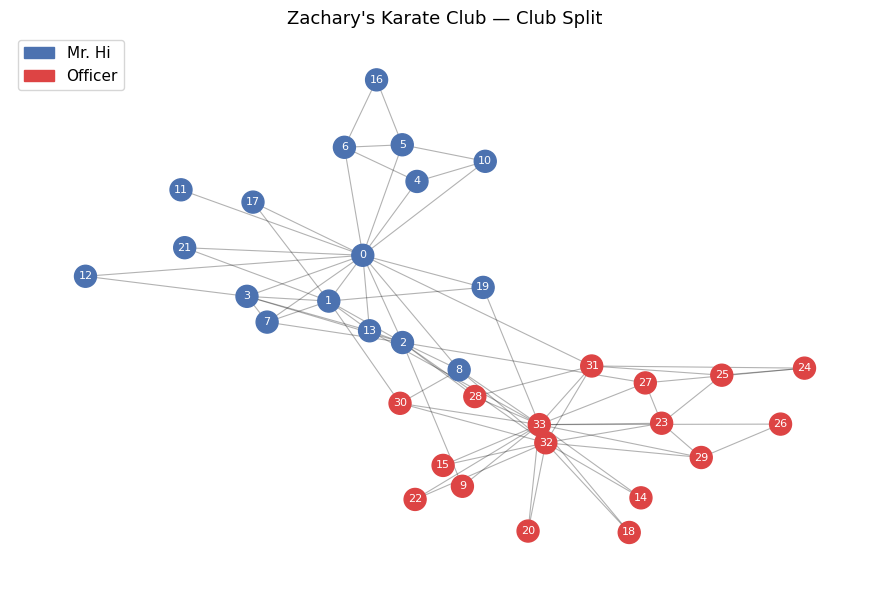

In [68]:
# ── Load graph ────────────────────────────────────────────────────────────────
G = nx.karate_club_graph()

# ── 1. Visualize with club-split coloring ─────────────────────────────────────
club_labels = nx.get_node_attributes(G, "club")  # "Mr. Hi" or "Officer"
color_map   = {"Mr. Hi": "#4C72B0", "Officer": "#DD4444"}
node_colors = [color_map[club_labels[n]] for n in G.nodes()]

pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(9, 6))
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.8, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=250, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color="white", ax=ax)

legend_handles = [
    mpatches.Patch(color="#4C72B0", label="Mr. Hi"),
    mpatches.Patch(color="#DD4444", label="Officer"),
]
ax.legend(handles=legend_handles, fontsize=11, loc="upper left")
ax.set_title("Zachary's Karate Club — Club Split", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("karate_club.png", dpi=150)
plt.show()


In [78]:
# ── 2. Modularity function (eq. 9.12) ─────────────────────────────────────────
def compute_modularity(G, partition):
    """
    Q = Σ_c [ L_c/m  -  (d_c / 2m)² ]

    where for each community c:
      L_c = number of edges within c
      d_c = sum of degrees of nodes in c
      m   = total number of edges
    """
    m = G.number_of_edges()
    if m == 0:
        return 0.0

    degrees = dict(G.degree())

    # Group nodes by community
    communities = defaultdict(list)
    for node, comm in partition.items():
        communities[comm].append(node)

    Q = 0.0
    for comm, members in communities.items():
        member_set = set(members)
        # L_c: edges with both endpoints in this community
        L_c = sum(1 for u, v in G.edges(members) if v in member_set)
        # d_c: sum of degrees in this community
        d_c = sum(degrees[n] for n in members)

        Q += (L_c / m) - (d_c / (2 * m)) ** 2

    return Q

In [79]:
# ── 4. Modularity of the club split ──────────────────────────────────────────
partition_club = nx.get_node_attributes(G, "club")
Q_club = compute_modularity(G, partition_club)
print(f"Modularity of club split: Q = {Q_club:.4f}")

Modularity of club split: Q = 0.3582


In [80]:
# ── 5. Double edge swap for undirected graph ──────────────────────────────────
def double_edge_swap_undirected(G, n_swaps=None):
    """Configuration model via double edge swap for undirected graphs."""
    H = G.copy()
    edges = list(H.edges())
    edge_set = set(frozenset(e) for e in edges)

    E = len(edges)
    if n_swaps is None:
        n_swaps = 10 * E

    successful = 0
    attempts   = 0
    max_attempts = 100 * n_swaps

    while successful < n_swaps and attempts < max_attempts:
        attempts += 1

        idx1, idx2 = random.sample(range(len(edges)), 2)
        u, v = edges[idx1]
        x, y = edges[idx2]

        # 50% flip
        if random.random() < 0.5:
            u, v = v, u

        if len({u, v, x, y}) < 4:   # need 4 distinct nodes
            continue

        e1_new = frozenset({u, y})
        e2_new = frozenset({x, v})

        if e1_new in edge_set or e2_new in edge_set:
            continue

        # Remove old, add new
        edge_set.discard(frozenset({u, v}))
        edge_set.discard(frozenset({x, y}))
        edge_set.add(e1_new)
        edge_set.add(e2_new)

        edges[idx1] = (u, y)
        edges[idx2] = (x, v)

        H.remove_edge(u, v)
        H.remove_edge(x, y)
        H.add_edge(u, y)
        H.add_edge(x, v)

        successful += 1

    return H


In [81]:
# ── 5 & 6. Generate 1000 random networks and compute modularity ───────────────
N_RANDOM = 1000
random_Q = []

print(f"\nGenerating {N_RANDOM} random networks...")
for i in range(N_RANDOM):
    H = double_edge_swap_undirected(G)
    q = compute_modularity(H, partition_club)
    random_Q.append(q)
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{N_RANDOM} done")

random_Q = np.array(random_Q)
print(f"\nRandom modularity — mean: {random_Q.mean():.4f}, std: {random_Q.std():.4f}")

p_val = np.mean(random_Q >= Q_club)
n = len(random_Q)
p_str = f"< {1/n:.3f}" if p_val == 0 else f"= {p_val:.4f}"


Generating 1000 random networks...
  100/1000 done
  200/1000 done
  300/1000 done
  400/1000 done
  500/1000 done
  600/1000 done
  700/1000 done
  800/1000 done
  900/1000 done
  1000/1000 done

Random modularity — mean: -0.0209, std: 0.0467


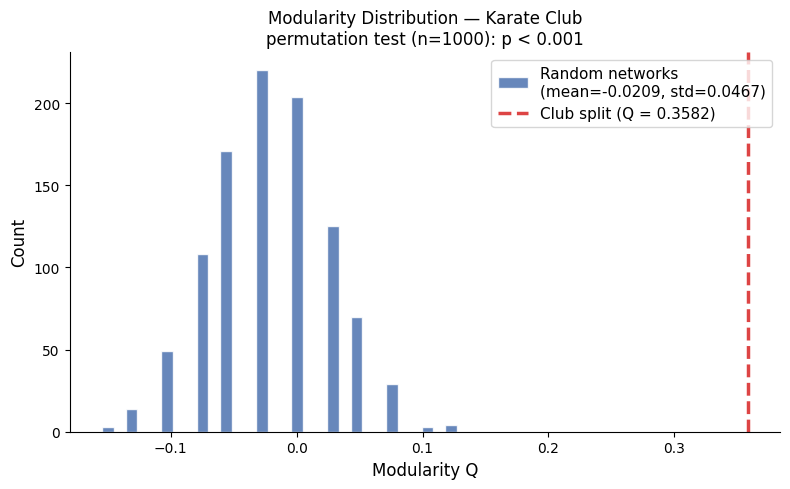

In [82]:
# ── 7. Plot distribution ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(random_Q, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85,
        label=f"Random networks\n(mean={random_Q.mean():.4f}, std={random_Q.std():.4f})")
ax.axvline(Q_club, color="#DD4444", linewidth=2.5, linestyle="--",
           label=f"Club split (Q = {Q_club:.4f})")
ax.set_xlabel("Modularity Q", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(f"Modularity Distribution — Karate Club\n"
             f"permutation test (n={n}): p {p_str}", fontsize=12)
ax.legend(fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("karate_modularity.png", dpi=150)
plt.show()

In [83]:
# ── 9. Louvain community detection ────────────────────────────────────────────
import community as community_louvain   # python-louvain

partition_louvain = community_louvain.best_partition(G)
Q_louvain = community_louvain.modularity(partition_louvain, G)
n_communities = len(set(partition_louvain.values()))

print(f"\nLouvain communities found : {n_communities}")
print(f"Louvain modularity        : Q = {Q_louvain:.4f}")
print(f"Club split modularity     : Q = {Q_club:.4f}")
print(f"Louvain {'higher' if Q_louvain > Q_club else 'lower'} than club split")



Louvain communities found : 4
Louvain modularity        : Q = 0.4449
Club split modularity     : Q = 0.3582
Louvain higher than club split



Confusion matrix D (4 Louvain communities × 2 club groups):
            Mr. Hi     Officer
  C0             1          11
  C1            11           0
  C2             5           0
  C3             0           6


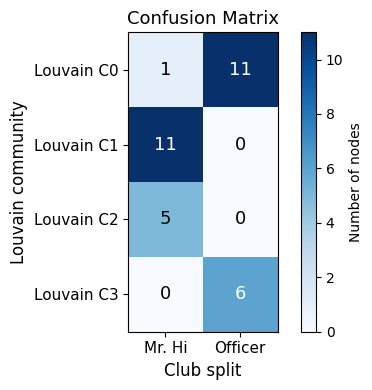

In [84]:
# ── 10. Confusion matrix ──────────────────────────────────────────────────────
club_groups   = sorted(set(partition_club.values()))    # ["Mr. Hi", "Officer"]
louvain_comms = sorted(set(partition_louvain.values())) # [0, 1, ...] — A communities

A = len(louvain_comms)   # number of Louvain communities
D = np.zeros((A, 2), dtype=int)   # rows = Louvain, cols = club split

col_index = {g: i for i, g in enumerate(club_groups)}

for node in G.nodes():
    row = louvain_comms.index(partition_louvain[node])
    col = col_index[partition_club[node]]
    D[row, col] += 1

print(f"\nConfusion matrix D ({A} Louvain communities × 2 club groups):")
print(f"  {'':>4}  {club_groups[0]:>10}  {club_groups[1]:>10}")
for i, comm in enumerate(louvain_comms):
    print(f"  C{comm:<3}  {D[i,0]:>10}  {D[i,1]:>10}")

# Visualise confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(D, cmap="Blues")
ax.set_xticks(range(2))
ax.set_xticklabels(club_groups, fontsize=11)
ax.set_yticks(range(A))
ax.set_yticklabels([f"Louvain C{c}" for c in louvain_comms], fontsize=11)
ax.set_xlabel("Club split", fontsize=12)
ax.set_ylabel("Louvain community", fontsize=12)
ax.set_title("Confusion Matrix", fontsize=13)

for i in range(A):
    for j in range(2):
        ax.text(j, i, D[i, j], ha="center", va="center",
                fontsize=13, color="white" if D[i,j] > D.max()/2 else "black")

plt.colorbar(im, ax=ax, label="Number of nodes")
plt.tight_layout()
plt.savefig("karate_confusion_matrix.png", dpi=150)
plt.show()

Q9. Louvain vs Club Split

The Louvain algorithm finds 4 communities with Q = 0.44, which is higher than the club split's Q = 0.36. This is expected since Louvain directly optimizes modularity, so it will always find a partition at least as good as any fixed partition like the club split.
The fact that Louvain Q is higher tells us the binary club split is a good but not optimal description of the network's community structure. The network contains finer-grained structure than the simple two-way social split captures — specifically, each faction contains internal sub-groups that are more densely connected internally than the two-faction model accounts for.
However, the gap is relatively modest (0.44 vs 0.36), which suggests the club split is still a meaningful and reasonable partition — it just doesn't capture everything. If the club split were completely arbitrary, Louvain would find a much higher Q by comparison. The social divide between Mr. Hi's group and the Officer's group is therefore a real structural feature of the network, even if not the finest-grained one algorithmically detectable.

Q10. Confusion matrix interpretation

The confusion matrix is nearly block-diagonal with respect to the club split, confirming the split is a meaningful partition, while the 4-community solution reveals sub-group structure within each faction that the binary split misses.

> __Exercise 4__: Community detection on the network of Computational Social Scientists. 
>
> * Consider the network of Computational Social Scientists. 
> * Use [the Python Louvain-algorithm implementation](https://anaconda.org/auto/python-louvain) to find communities. How many communities do you find? What are their sizes? Report the value of modularity found by the algorithm. Is the modularity significantly different than 0? 
> * If you are curious, you can also try the *Infomap* algorithm. Go to [this page](https://mapequation.github.io/infomap/python/). It's harder to install, but a better community detection algorithm. You can read about it in [advanced topics 9B](http://networksciencebook.com/chapter/9#advanced-9b).
> * Visualize the network, using netwulf (see Week 5). This time assign each node a different color based on their _community_. Describe the structure you observe.
> * Make sure you save the assignment of authors to communities.


In [85]:
"""
Exercise 4: Community Detection on the CSS Network
Louvain community detection, significance test, and visualization.
Assumes: G (directed NetworkX graph of GCC), node_attr, double_edge_swap()
from previous exercises.
"""

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter, defaultdict
import random
import json
import community as community_louvain

In [86]:
# ── Build undirected version for community detection ─────────────────────────
# Louvain works on undirected graphs
G_undirected = G.to_undirected()

# ── Run Louvain ───────────────────────────────────────────────────────────────
partition = community_louvain.best_partition(G_undirected, random_state=42)
Q_louvain = community_louvain.modularity(partition, G_undirected)

n_communities = len(set(partition.values()))
community_sizes = Counter(partition.values())
community_sizes_sorted = sorted(community_sizes.items(), key=lambda x: -x[1])

print(f"Number of communities : {n_communities}")
print(f"Louvain modularity    : Q = {Q_louvain:.4f}")
print(f"\nCommunity sizes (largest first):")
for comm_id, size in community_sizes_sorted:
    print(f"  Community {comm_id:>2}: {size:>4} nodes")

Number of communities : 4
Louvain modularity    : Q = 0.4439

Community sizes (largest first):
  Community  3:   14 nodes
  Community  0:   11 nodes
  Community  1:    5 nodes
  Community  2:    4 nodes


In [87]:
# ── Significance test: compare Q against 100 config-model networks ────────────
# Reuse double_edge_swap_undirected from Exercise 3 (undirected version)
def double_edge_swap_undirected_css(edges, n_swaps=None):
    """Double edge swap for undirected edge list (no nx Graph needed)."""
    edge_list = list(edges)
    edge_set  = set(frozenset(e) for e in edge_list)
    E = len(edge_list)
    if n_swaps is None:
        n_swaps = 10 * E

    successful = 0
    attempts   = 0
    max_attempts = 100 * n_swaps

    while successful < n_swaps and attempts < max_attempts:
        attempts += 1
        idx1, idx2 = random.sample(range(len(edge_list)), 2)
        u, v = edge_list[idx1]
        x, y = edge_list[idx2]
        if random.random() < 0.5:
            u, v = v, u
        if len({u, v, x, y}) < 4:
            continue
        e1_new = frozenset({u, y})
        e2_new = frozenset({x, v})
        if e1_new in edge_set or e2_new in edge_set:
            continue
        edge_set.discard(frozenset({u, v}))
        edge_set.discard(frozenset({x, y}))
        edge_set.add(e1_new)
        edge_set.add(e2_new)
        edge_list[idx1] = (u, y)
        edge_list[idx2] = (x, v)
        successful += 1

    return edge_list

N_RANDOM = 100
random_Q = []
undirected_edges = list(G_undirected.edges())
nodes_list = list(G_undirected.nodes())

print(f"\nRunning significance test ({N_RANDOM} random networks)...")
for i in range(N_RANDOM):
    rand_edges = double_edge_swap_undirected_css(undirected_edges)
    H = nx.Graph()
    H.add_nodes_from(nodes_list)
    H.add_edges_from([tuple(e) for e in rand_edges])
    rand_partition = community_louvain.best_partition(H, random_state=i)
    q = community_louvain.modularity(rand_partition, H)
    random_Q.append(q)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_RANDOM}  Q = {q:.4f}")

random_Q = np.array(random_Q)
p_val = np.mean(random_Q >= Q_louvain)
n = len(random_Q)
p_str = f"< {1/n:.2f}" if p_val == 0 else f"= {p_val:.4f}"

print(f"\nRandom Q — mean: {random_Q.mean():.4f}, std: {random_Q.std():.4f}")
print(f"Permutation p {p_str}  →  {'significant' if p_val < 0.05 else 'not significant'}")


Running significance test (100 random networks)...
  10/100  Q = 0.2967
  20/100  Q = 0.2915
  30/100  Q = 0.3387
  40/100  Q = 0.3001
  50/100  Q = 0.2795
  60/100  Q = 0.3000
  70/100  Q = 0.2914
  80/100  Q = 0.2959
  90/100  Q = 0.2670
  100/100  Q = 0.3073

Random Q — mean: 0.2961, std: 0.0173
Permutation p < 0.01  →  significant


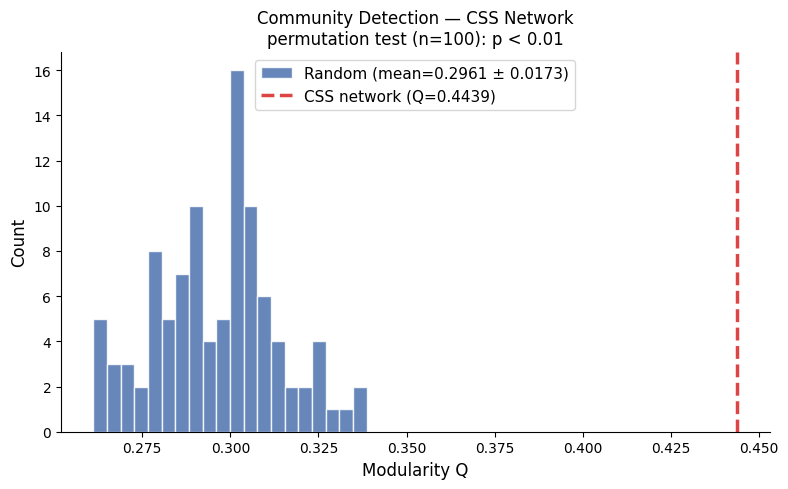

In [88]:
# ── Plot modularity distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(random_Q, bins=20, color="#4C72B0", edgecolor="white", alpha=0.85,
        label=f"Random (mean={random_Q.mean():.4f} ± {random_Q.std():.4f})")
ax.axvline(Q_louvain, color="#DD4444", linewidth=2.5, linestyle="--",
           label=f"CSS network (Q={Q_louvain:.4f})")
ax.set_xlabel("Modularity Q", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(f"Community Detection — CSS Network\n"
             f"permutation test (n={n}): p {p_str}", fontsize=12)
ax.legend(fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("css_modularity_distribution.png", dpi=150)
plt.show()


Computing layout (this may take a moment for large networks)...


/var/folders/4p/ys3rkz1x60xcwx4pzd453jt40000gn/T/ipykernel_76850/2785046630.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_communities)


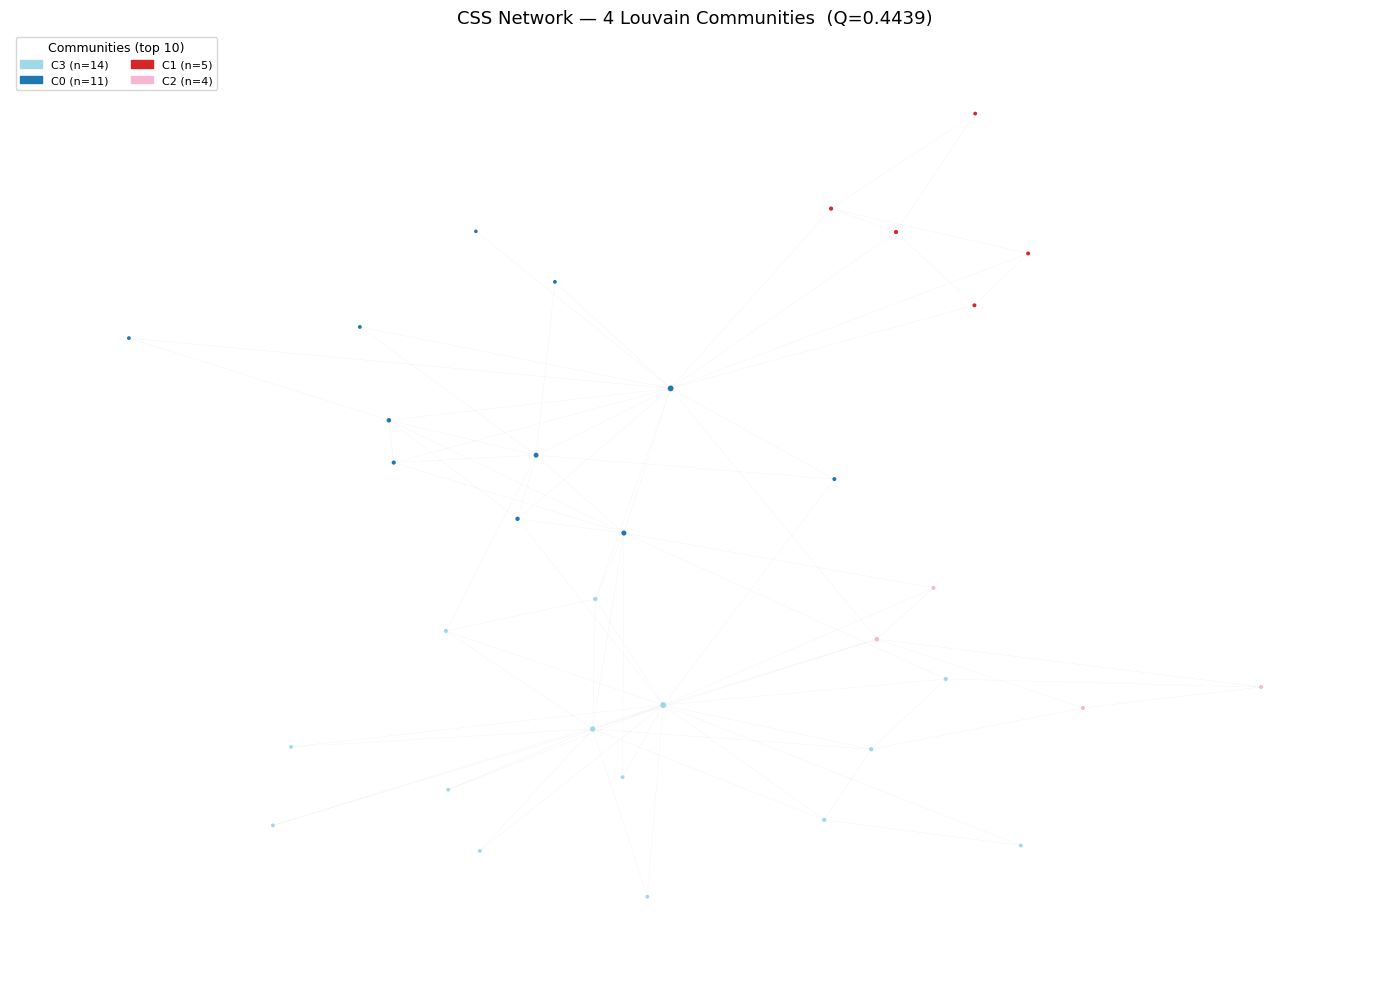

In [89]:
# ── Visualization colored by community ────────────────────────────────────────
# Use a colormap with enough distinct colors
cmap = cm.get_cmap("tab20", n_communities)
node_colors = [cmap(partition[n]) for n in G_undirected.nodes()]

# Spring layout — use degree as node size for readability
degrees = dict(G_undirected.degree())
node_sizes = [2 + degrees[n] * 0.5 for n in G_undirected.nodes()]

print("\nComputing layout (this may take a moment for large networks)...")
pos = nx.spring_layout(G_undirected, seed=42, k=0.3)

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(G_undirected, pos, alpha=0.05, width=0.3, ax=ax)
nx.draw_networkx_nodes(G_undirected, pos,
                       node_color=node_colors,
                       node_size=node_sizes,
                       ax=ax)

# Legend: one patch per community (show top 10 by size)
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color=cmap(comm_id),
                   label=f"C{comm_id} (n={size})")
    for comm_id, size in community_sizes_sorted[:10]
]
ax.legend(handles=legend_handles, fontsize=8, loc="upper left",
          title="Communities (top 10)", title_fontsize=9,
          ncol=2, framealpha=0.8)

ax.set_title(f"CSS Network — {n_communities} Louvain Communities  (Q={Q_louvain:.4f})",
             fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("css_communities.png", dpi=150)
plt.show()

In [90]:
# ── Save community assignments ────────────────────────────────────────────────
# Map back to display names for readability
community_assignment = {}
for node, comm in partition.items():
    display = G.nodes[node].get("display_name", node)
    community_assignment[node] = {
        "display_name": display,
        "community": comm,
        "country_code": node_attr.get(node, None)
    }

with open("css_community_assignments.json", "w") as f:
    json.dump(community_assignment, f, indent=2)

print(f"\nCommunity assignments saved to css_community_assignments.json")
print(f"Summary: {n_communities} communities, largest has "
      f"{community_sizes_sorted[0][1]} nodes")


Community assignments saved to css_community_assignments.json
Summary: 4 communities, largest has 14 nodes
